## Proyecto 2: Entrenamiento del Modelo

El dataset utilizado para este proyecto se puede encontrar en el siguiente enlace: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection?select=Dataset

In [2]:
#imports

import random
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torchvision.transforms.functional as TF
import torch.onnx
import onnxruntime as ort

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [4]:
#Usar dataset local
model_dir = Path.cwd()
if model_dir.name != "Modelo" and (model_dir / "Modelo").exists():
    model_dir = model_dir / "Modelo"

subset_root = model_dir / "data" / "tomato_subset"

print("Dataset local:", subset_root)
print("Existe:", subset_root.exists())

Dataset local: c:\Users\diego\OneDrive\Documentos\GitHub\Escuela\ICProyecto2\Modelo\data\tomato_subset
Existe: True


In [5]:
#Clases objetivo
TOMATO_CLASSES = [
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy"
]

CLASS_ALIASES = {
    "Tomato_Spider_mites_Two_spotted_spider_mite": "tomato_spider_mide",
}

def class_alias(class_name):
    return CLASS_ALIASES.get(class_name, class_name)

def graph_label(class_name):
    label = class_alias(class_name)
    changed = True

    while changed:
        changed = False
        for prefix in ("Tomato__", "Tomato_", "tomato_"):
            if label.startswith(prefix):
                label = label[len(prefix):]
                changed = True

    return label

## EDA

### Size

In [6]:
#Dataset size
class_counts = {}
total_images = 0

for class_name in TOMATO_CLASSES:
    count = len(list((subset_root / class_name).glob("*.jpg")))
    class_counts[class_name] = count
    total_images += count

print("Total images in tomato subset:", total_images)
print("\nImages per class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Total images in tomato subset: 16010

Images per class:
Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_Late_blight: 1908
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Target_Spot: 1404
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208
Tomato__Tomato_mosaic_virus: 373
Tomato_healthy: 1591


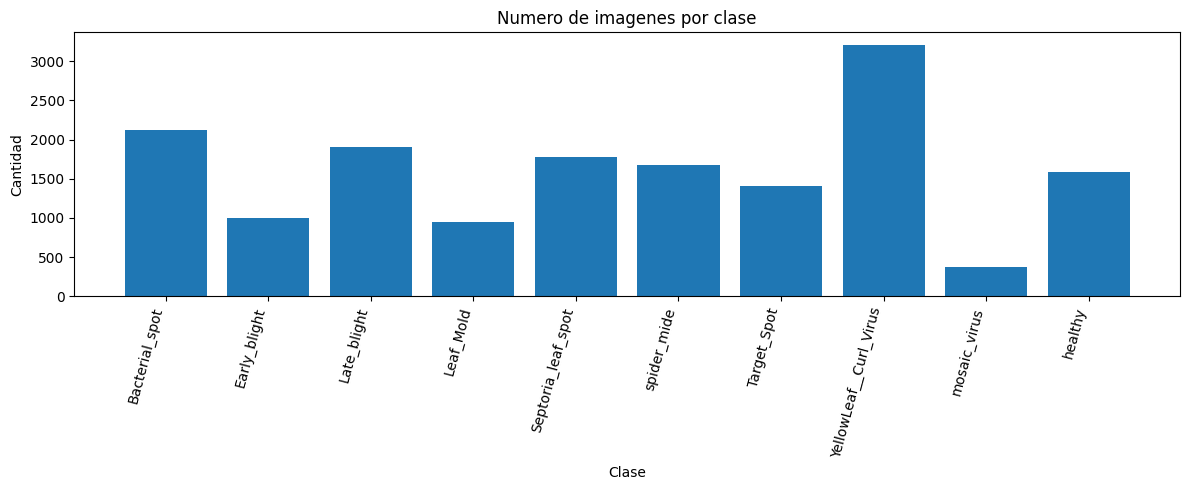

In [7]:
#Distribucion de clases
plt.figure(figsize=(12, 5))
graph_labels = [graph_label(class_name) for class_name in class_counts.keys()]

plt.bar(graph_labels, class_counts.values())
plt.xticks(rotation=75, ha="right")
plt.title("Numero de imagenes por clase")
plt.ylabel("Cantidad")
plt.xlabel("Clase")
plt.tight_layout()
plt.show()

### Image dimensions

In [8]:
all_image_paths = []
for class_name in TOMATO_CLASSES:
    all_image_paths.extend(list((subset_root / class_name).glob("*.jpg")))

sample_paths = random.sample(all_image_paths, min(300, len(all_image_paths)))

sizes = []
for img_path in sample_paths:
    with Image.open(img_path) as img:
        sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print("Width min/max:", min(widths), max(widths))
print("Height min/max:", min(heights), max(heights))
print("Example dimensions:", sizes[:10])

Width min/max: 256 256
Height min/max: 256 256
Example dimensions: [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]


### Examples of each class

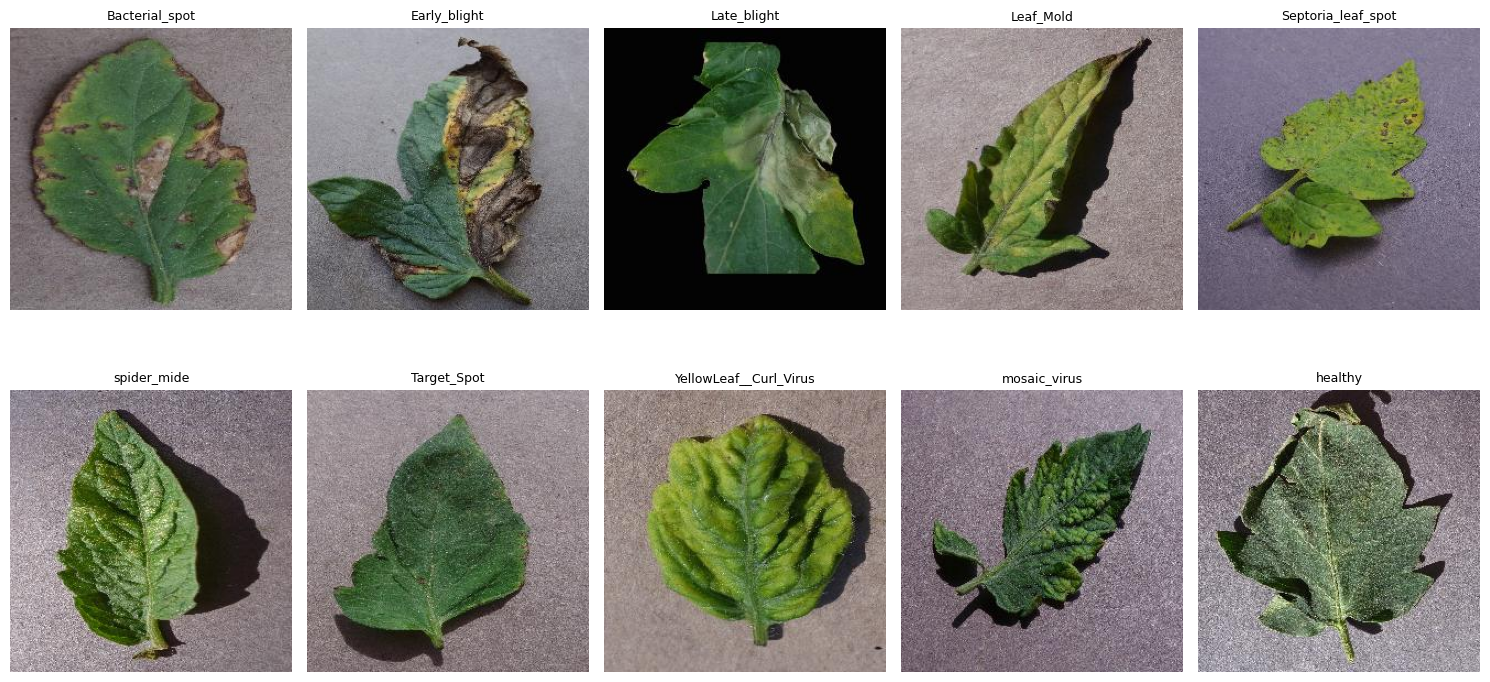

In [9]:
#Una imagen por clase
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(TOMATO_CLASSES, 1):
    class_dir = subset_root / class_name
    image_paths = [
        img_path for img_path in class_dir.iterdir()
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    if not image_paths:
        continue

    img_path = random.choice(image_paths)
    img = Image.open(img_path).convert("RGB")

    plt.subplot(2, 5, i)
    plt.imshow(img)
    plt.title(graph_label(class_name), fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Conclusion de EDA

El EDA mostró que el subconjunto de tomate es adecuado para un problema de clasificación multiclase, ya que cuenta con 16,010 imágenes repartidas en 10 clases. También se observó que todas las imágenes tienen un tamaño uniforme de 256×256 píxeles, lo que facilita su uso en modelos de deep learning. No obstante, existe cierto desbalance entre clases, pues algunas tienen muchas más imágenes que otras. En general, el dataset se ve consistente y suficiente para entrenar modelos de redes neuronales convolucionales.



## Preprocesamiento

In [10]:
# Definición de transformaciones para entrenamiento (data augmentation)  validación y entrenamiento (estandarización)

IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomRotation(20),  # hojas pueden rotar
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
# Cargar dataset completo

full_dataset = datasets.ImageFolder(
    root=subset_root,
    transform=None
)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Clases:", class_names)
print("Número de clases:", num_classes)

Clases: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Número de clases: 10


In [12]:
# Dividir dataset en entrenamiento, validación y prueba

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

12808 1601 1601


In [13]:
# Aplicar trasformaciones y generar data loaders

class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        x = self.transform(x)
        return x, y


train_dataset = TransformedDataset(train_dataset, train_transforms)
val_dataset = TransformedDataset(val_dataset, val_test_transforms)
test_dataset = TransformedDataset(test_dataset, val_test_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Generar pesos de clases para que la función de pérdida de más peso a errores en clases menos comunes

targets = [full_dataset[idx][1] for idx in train_dataset.subset.indices]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(targets),
    y=targets
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

## Entrenamiento de los Modelos

In [14]:
# Función para obtener accuracy por batch

def get_batch_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

# Función de entrenamiento con data augmentation y retorno del registro de pérdida y accuracy para curvas de aprendizaje

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        start_time = time.time()

        # Entrenamiento
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for X_batch, y_batch in loop:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * X_batch.size(0)
            running_correct += (preds == y_batch).sum().item()
            running_total += y_batch.size(0)

            batch_acc = (preds == y_batch).sum().item() / y_batch.size(0)

            loop.set_postfix(loss=loss.item(), acc=batch_acc)

        epoch_train_loss = running_loss / running_total
        epoch_train_acc = running_correct / running_total

        # validación
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                outputs = model(X_val)
                loss = criterion(outputs, y_val)

                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * X_val.size(0)
                val_correct += (preds == y_val).sum().item()
                val_total += y_val.size(0)

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total

        # Guardar historial
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        end_time = time.time()

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}")
        print(f"Time: {end_time - start_time:.2f}s")

    return history

In [15]:
# Definición de función de pérdida

loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# Definición del modelo 1

model_1 = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(32 * 56 * 56, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
).to(device)

#Definición del modelo 2

model_2 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(128 * 28 * 28, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
).to(device)

#Definición del modelo 3

model_3 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(128 * 28 * 28, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
).to(device)

# Definir optimizadores y épocas
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)
optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.0005)
optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=0.0001)

num_epochs = 10

# Mostrar número de parámetros
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

param_data = {
    "Modelo": ["Modelo 1", "Modelo 2", "Modelo 3"],
    "Parámetros": [
        count_parameters(model_1),
        count_parameters(model_2),
        count_parameters(model_3)
    ]
}

df_params = pd.DataFrame(param_data)
df_params

,Modelo,Parámetros
0,Modelo 1,12851562
1,Modelo 2,25786186
2,Modelo 3,51525290


In [16]:
# Entrenamiento del modelo 1

history_1 = train_model(model_1, train_loader, val_loader, loss_fn, optimizer_1, num_epochs)


Epoch 1/10
Train Loss: 1.5126 | Train Acc: 0.5130
Val   Loss: 0.7662 | Val   Acc: 0.7383
Time: 84.01s



Epoch 2/10
Train Loss: 0.7215 | Train Acc: 0.7556
Val   Loss: 0.5022 | Val   Acc: 0.8413
Time: 72.76s



Epoch 3/10
Train Loss: 0.5881 | Train Acc: 0.8042
Val   Loss: 0.4698 | Val   Acc: 0.8301
Time: 72.33s



Epoch 4/10
Train Loss: 0.5221 | Train Acc: 0.8194
Val   Loss: 0.5377 | Val   Acc: 0.8051
Time: 68.85s



Epoch 5/10
Train Loss: 0.4654 | Train Acc: 0.8410
Val   Loss: 0.4448 | Val   Acc: 0.8601
Time: 82.01s



Epoch 6/10
Train Loss: 0.4439 | Train Acc: 0.8478
Val   Loss: 0.3906 | Val   Acc: 0.8757
Time: 83.69s



Epoch 7/10
Train Loss: 0.4045 | Train Acc: 0.8609
Val   Loss: 0.3254 | Val   Acc: 0.8888
Time: 85.90s



Epoch 8/10
Train Loss: 0.4020 | Train Acc: 0.8662
Val   Loss: 0.3865 | Val   Acc: 0.8595
Time: 77.99s



Epoch 9/10
Train Loss: 0.3669 | Train Acc: 0.8755
Val   Loss: 0.2797 | Val   Acc: 0.9007
Time: 78.68s



Epoch 10/10
Train Loss: 0.3312 | Train Acc: 0.8849
Val   Loss: 0.2745 | Val   Acc: 0.9113
Time: 92.53s


In [17]:
# Entrenamiento del modelo 2

history_2 = train_model(model_2, train_loader, val_loader, loss_fn, optimizer_2, num_epochs)



Epoch 1/10
Train Loss: 1.1381 | Train Acc: 0.6127
Val   Loss: 0.5024 | Val   Acc: 0.8220
Time: 82.25s



Epoch 2/10
Train Loss: 0.6098 | Train Acc: 0.7922
Val   Loss: 0.3367 | Val   Acc: 0.8876
Time: 78.56s



Epoch 3/10
Train Loss: 0.4762 | Train Acc: 0.8368
Val   Loss: 0.2864 | Val   Acc: 0.9076
Time: 87.68s



Epoch 4/10
Train Loss: 0.4310 | Train Acc: 0.8554
Val   Loss: 0.2651 | Val   Acc: 0.9119
Time: 90.44s



Epoch 5/10
Train Loss: 0.3617 | Train Acc: 0.8770
Val   Loss: 0.2152 | Val   Acc: 0.9275
Time: 92.75s



Epoch 6/10
Train Loss: 0.3209 | Train Acc: 0.8962
Val   Loss: 0.2173 | Val   Acc: 0.9369
Time: 93.47s



Epoch 7/10
Train Loss: 0.2934 | Train Acc: 0.8973
Val   Loss: 0.1671 | Val   Acc: 0.9444
Time: 87.90s



Epoch 8/10
Train Loss: 0.2563 | Train Acc: 0.9152
Val   Loss: 0.1595 | Val   Acc: 0.9419
Time: 84.67s



Epoch 9/10
Train Loss: 0.2621 | Train Acc: 0.9151
Val   Loss: 0.1448 | Val   Acc: 0.9575
Time: 76.87s



Epoch 10/10
Train Loss: 0.2096 | Train Acc: 0.9283
Val   Loss: 0.1287 | Val   Acc: 0.9557
Time: 95.78s


In [18]:
# Entrenamiento del modelo 3

history_3 = train_model(model_3, train_loader, val_loader, loss_fn, optimizer_3, num_epochs)


Epoch 1/10
Train Loss: 1.5484 | Train Acc: 0.4826
Val   Loss: 0.9668 | Val   Acc: 0.6746
Time: 131.22s



Epoch 2/10
Train Loss: 0.9273 | Train Acc: 0.6882
Val   Loss: 0.5845 | Val   Acc: 0.8076
Time: 112.40s



Epoch 3/10
Train Loss: 0.7342 | Train Acc: 0.7470
Val   Loss: 0.4734 | Val   Acc: 0.8326
Time: 110.83s



Epoch 4/10
Train Loss: 0.6367 | Train Acc: 0.7810
Val   Loss: 0.3785 | Val   Acc: 0.8663
Time: 127.11s



Epoch 5/10
Train Loss: 0.5478 | Train Acc: 0.8109
Val   Loss: 0.3426 | Val   Acc: 0.8857
Time: 139.90s



Epoch 6/10
Train Loss: 0.5029 | Train Acc: 0.8294
Val   Loss: 0.3016 | Val   Acc: 0.9001
Time: 140.39s



Epoch 7/10
Train Loss: 0.4654 | Train Acc: 0.8376
Val   Loss: 0.2690 | Val   Acc: 0.9126
Time: 121.14s



Epoch 8/10
Train Loss: 0.4233 | Train Acc: 0.8579
Val   Loss: 0.2400 | Val   Acc: 0.9194
Time: 122.66s



Epoch 9/10
Train Loss: 0.3915 | Train Acc: 0.8684
Val   Loss: 0.2318 | Val   Acc: 0.9269
Time: 119.68s



Epoch 10/10
Train Loss: 0.3837 | Train Acc: 0.8703
Val   Loss: 0.2095 | Val   Acc: 0.9300
Time: 126.74s


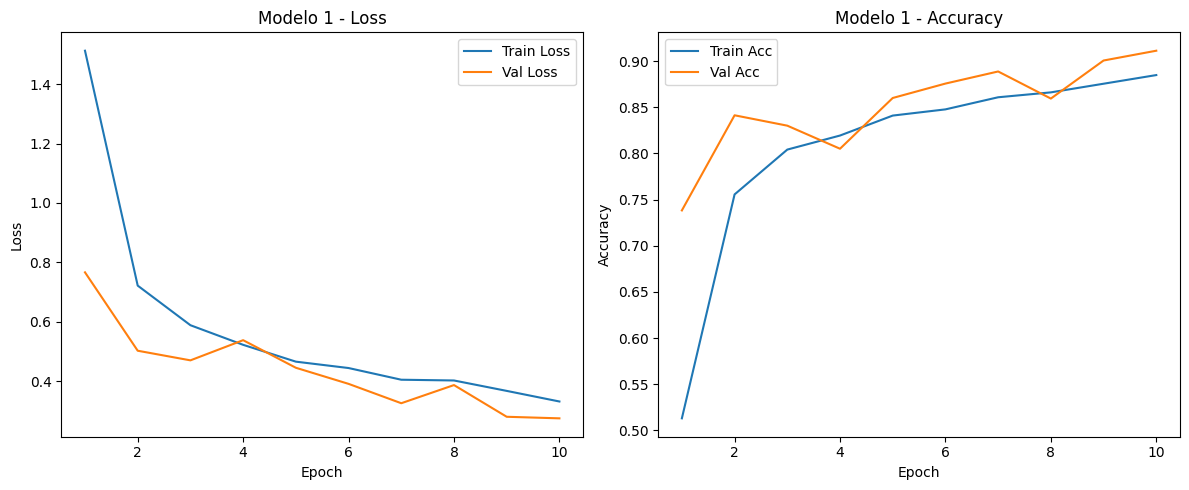

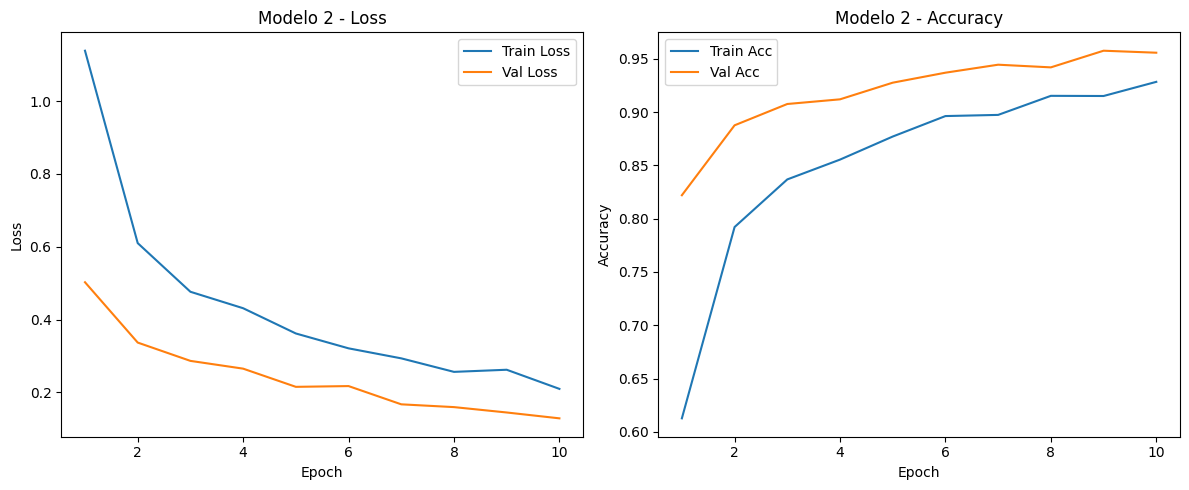

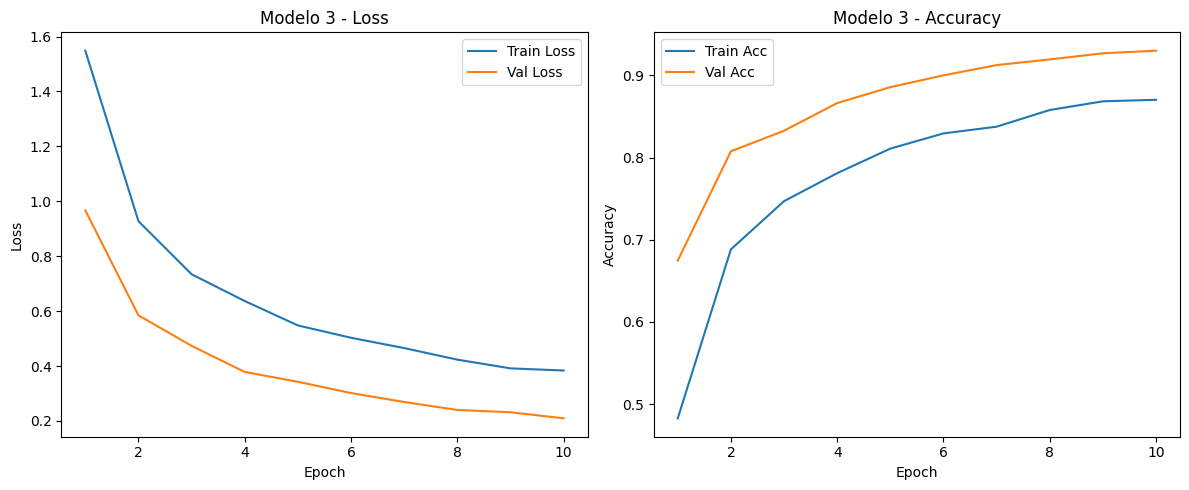

In [19]:
# Mostrar curvas de aprendizaje

def plot_learning_curves(history, title):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Pérdida
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_1, "Modelo 1")
plot_learning_curves(history_2, "Modelo 2")
plot_learning_curves(history_3, "Modelo 3")

### Elección del Mejor Modelo

In [20]:
# Mostrar resultados de los modelos en evaluación

def evaluate_model_with_time(model, dataloader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    start_time = time.time()

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            total_loss += loss.item() * X.size(0)

            _, preds = torch.max(outputs, 1)
            total_correct += (preds == y).sum().item()
            total_samples += y.size(0)

    end_time = time.time()

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    total_time = end_time - start_time
    time_per_batch = total_time / len(dataloader)

    return avg_loss, accuracy, total_time, time_per_batch

results = []

models = [model_1, model_2, model_3]
model_names = ["Modelo 1", "Modelo 2", "Modelo 3"]

for name, model in zip(model_names, models):
    val_loss, val_acc, total_time, batch_time = evaluate_model_with_time(
        model, val_loader, loss_fn
    )

    results.append({
        "Modelo": name,
        "Val Loss": val_loss,
        "Val Accuracy": val_acc,
        "Tiempo Total (s)": total_time,
        "Tiempo por Batch (s)": batch_time
    })


df_results = pd.DataFrame(results)

df_results

,Modelo,Val Loss,Val Accuracy,Tiempo Total (s),Tiempo por Batch (s)
0,Modelo 1,0.274470,0.911305,4.840615,0.094914
1,Modelo 2,0.128671,0.955653,6.787017,0.133079
2,Modelo 3,0.209497,0.930044,11.091631,0.217483


In [21]:
# Elección del mejor modelo

best_model = model_2

## Evaluación del Modelo

-------- REPORTE EN TEST --------

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.95      0.95      0.95       201
                        Tomato_Early_blight       0.83      0.95      0.89       101
                         Tomato_Late_blight       0.97      0.88      0.93       199
                           Tomato_Leaf_Mold       0.95      0.96      0.96        81
                  Tomato_Septoria_leaf_spot       0.92      0.97      0.95       172
Tomato_Spider_mites_Two_spotted_spider_mite       0.90      0.94      0.92       174
                        Tomato__Target_Spot       0.93      0.91      0.92       136
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      0.93      0.96       322
                Tomato__Tomato_mosaic_virus       0.88      1.00      0.93        50
                             Tomato_healthy       0.98      1.00      0.99       165

                            

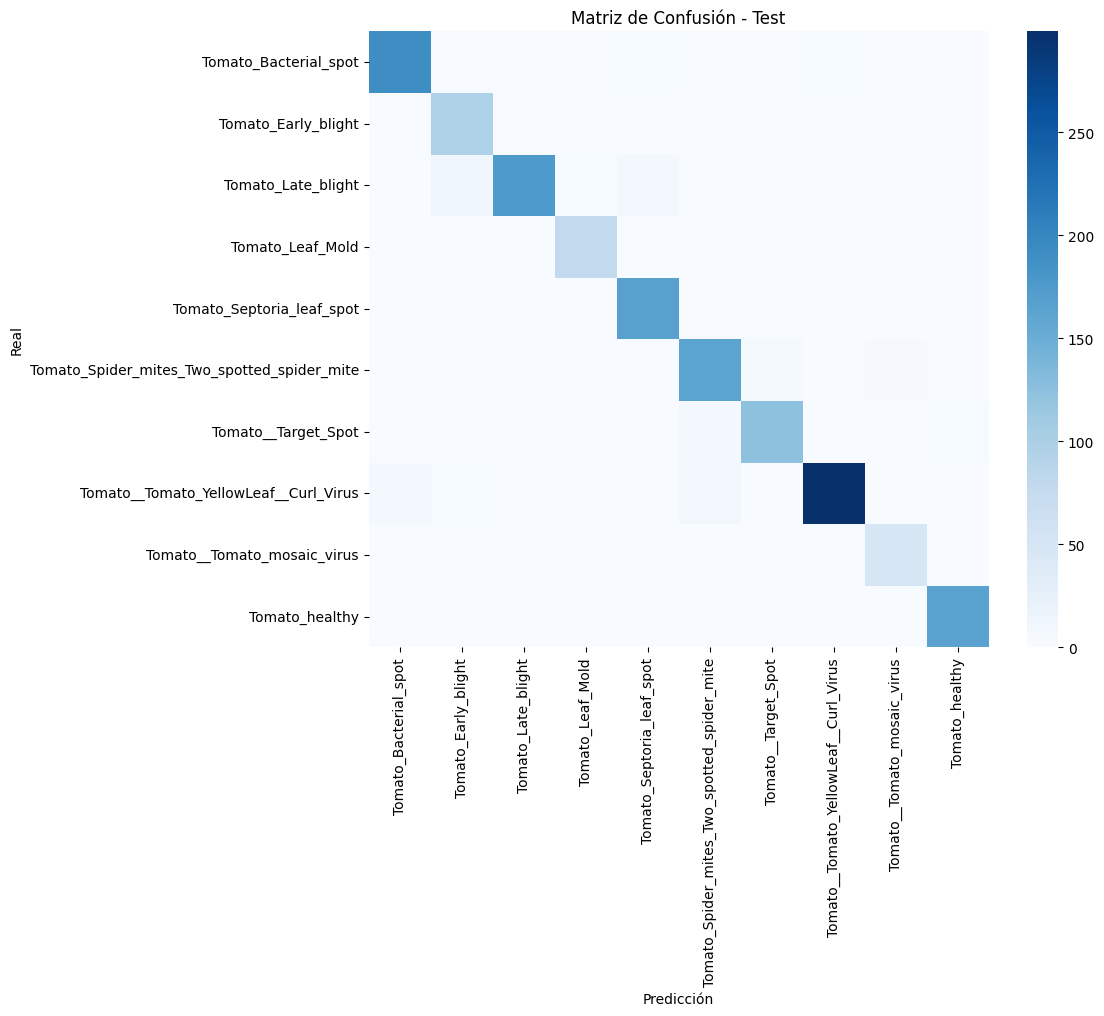

-------- REPORTE EN TRAIN --------

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.97      0.96      0.96      1711
                        Tomato_Early_blight       0.87      0.95      0.91       804
                         Tomato_Late_blight       0.98      0.90      0.94      1510
                           Tomato_Leaf_Mold       0.96      0.95      0.95       763
                  Tomato_Septoria_leaf_spot       0.92      0.96      0.94      1421
Tomato_Spider_mites_Two_spotted_spider_mite       0.93      0.96      0.95      1331
                        Tomato__Target_Spot       0.93      0.93      0.93      1132
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      0.95      0.97      2572
                Tomato__Tomato_mosaic_virus       0.93      0.99      0.96       290
                             Tomato_healthy       0.97      1.00      0.98      1274

                           

In [22]:
# Generar reportes de evaluación

best_model.eval()

def get_predictions(model, dataloader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)

            outputs = model(X)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_preds)

y_test, y_pred_test = get_predictions(best_model, test_loader)

print("-------- REPORTE EN TEST --------\n")
print(classification_report(y_test, y_pred_test, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - Test")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

y_train, y_pred_train = get_predictions(best_model, train_loader)

print("-------- REPORTE EN TRAIN --------\n")
print(classification_report(y_train, y_pred_train, target_names=class_names))

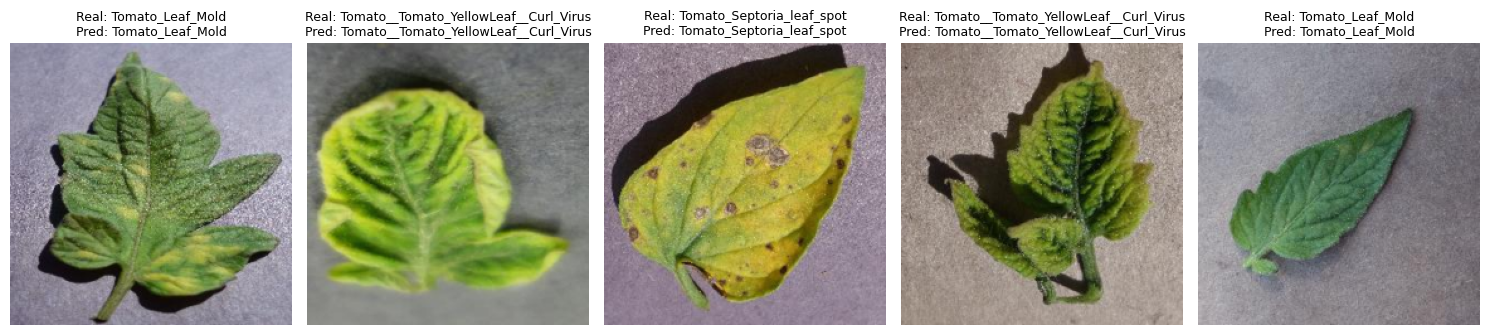

In [23]:
# Mostrar ejemplos aleatorios del conjunto de prueba

def show_predictions(model, dataset, class_names, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        input_img = img.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_img)
            _, pred = torch.max(output, 1)

        pred_label = class_names[pred.item()]
        true_label = class_names[label]

        # Desnormalizar para mostrar
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        img_np = np.clip(img_np, 0, 1)

        plt.subplot(1, num_images, i+1)
        plt.imshow(img_np)
        plt.title(f"Real: {true_label}\nPred: {pred_label}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(best_model, test_dataset, class_names, num_images=5)

## Serialización del Modelo

In [ ]:
# Serializar el modelo
dummy_input = torch.randn(1, 3, 224, 224).to(device)

onnx_path = "best_model_project_2.onnx"

torch.onnx.export(
    best_model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"Modelo exportado a {onnx_path}")

C:\Users\diego\AppData\Local\Temp\ipykernel_15732\2258234535.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0423 17:42:21.510807 15732 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...


W0423 17:42:22.761690 15732 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\diego\AppData\Local\Programs\Python\Python310\lib\copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
  File "c:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "c:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-pa

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Modelo exportado a best_model_project_2.onnx


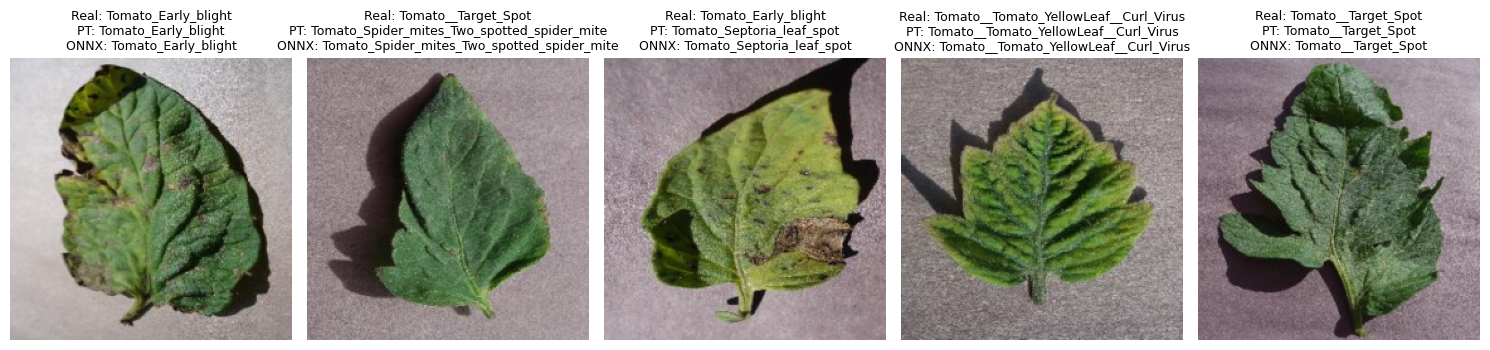

In [27]:
# Prueba de serialización

ort_session = ort.InferenceSession(onnx_path)

def predict_onnx(session, input_tensor):
    input_np = input_tensor.cpu().numpy()

    outputs = session.run(None, {"input": input_np})
    preds = np.argmax(outputs[0], axis=1)

    return preds

def compare_models(pytorch_model, onnx_session, dataset, class_names, num_images=5):
    pytorch_model.eval()

    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        # Preparar input
        input_tensor = img.unsqueeze(0).to(device)

        # Modelo de PyTorch
        with torch.no_grad():
            output_pt = pytorch_model(input_tensor)
            _, pred_pt = torch.max(output_pt, 1)

        # Modelo de onnx
        pred_onnx = predict_onnx(onnx_session, input_tensor)

        # Etiquetas
        true_label = class_names[label]
        pred_pt_label = class_names[pred_pt.item()]
        pred_onnx_label = class_names[pred_onnx[0]]

        # Desnormalizar
        img_np = img.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
        img_np = np.clip(img_np, 0, 1)

        plt.subplot(1, num_images, i+1)
        plt.imshow(img_np)
        plt.title(
            f"Real: {true_label}\n"
            f"PT: {pred_pt_label}\n"
            f"ONNX: {pred_onnx_label}",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

compare_models(best_model, ort_session, test_dataset, class_names, num_images=5)